# 36. Magnetocrystalline anisotropy

Which way a magnet wants to point. Cobalt in a stretched tetragonal cell prefers
its long axis, and the energy difference between pointing along that axis and
lying in the basal plane is what makes a hard magnet hard, what pins a spiral
into a plane, and what a recording medium is made of.

That energy is small: about a milli-electronvolt here, against a total energy of
seventy-four Rydberg. Taking it as a difference of two separately converged
calculations asks them to agree in their ninth digit. The **force theorem** does
not ask that. Converge the magnet with no spin-orbit coupling, turn the
converged density so its magnetization points where you want, and diagonalise
**once** with the coupling switched on. Nothing is re-converged, and the
anisotropy is the difference of the two sums of occupied energies.

On a three-layer cobalt film this gives **0.3458 meV** where `pw.x` gives
**0.3532 meV**.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from defumat import Calculator

PSEUDO, CASES = Path("../tests/data/pseudo"), Path("../tests/data/qe")

scalar = Calculator.from_file(CASES / "co-tetragonal-anisotropy-sr.in", PSEUDO,
                              announce=False)
spinor = Calculator.from_file(CASES / "co-tetragonal-anisotropy-soc.in", PSEUDO,
                              announce=False)

mae = scalar.get_anisotropy(spinor, directions="xz")
print(f"easy axis {mae.easy_axis}, anisotropy {mae.anisotropy_mev:.4f} meV")

easy axis (0.0, 0.0, 1.0), anisotropy 1.2353 meV


The easy axis comes out along `c`, and the crystal pays about a
milli-electronvolt to lie in the basal plane instead.

## Why it has to be a diagonalisation

The tempting shortcut is to freeze the wavefunctions as well and simply take the
expectation value of the spin-orbit term once. That returns **zero**, for a
reason worth knowing: spin-orbit coupling first appears as the orbital moment
dotted into the spin direction, and in a magnet without spin-orbit coupling the
orbital moment is quenched by the crystal field. There is nothing for the spin
direction to talk to.

The anisotropy is second order in the coupling. What produces it is the
repulsion between levels that the coupling causes, and only a diagonalisation
sees that.

In [2]:
from defumat.units import RY_TO_EV

first = [scalar.get_first_order_soc(spinor, direction=d) * RY_TO_EV * 1000
         for d in [(1, 0, 0), (0, 0, 1)]]
print(f"first order, in-plane and along c: {first[0]:+.6f}, {first[1]:+.6f} meV")
print(f"force theorem on the same density: {mae.anisotropy_mev:.6f} meV")

first order, in-plane and along c: -0.000001, +0.000002 meV
force theorem on the same density: 1.235307 meV


## The control: switch the coupling off

Without spin-orbit coupling the energy cannot depend on the moment's direction
at all, because nothing connects spin to the lattice. That is not an
approximation, it is a symmetry, and it makes a sharp test: the same calculation
with the coupling switched off inside the same pseudopotential must give a flat
line.

In [3]:
angles = [0, 30, 60, 90]
directions = [(np.sin(np.radians(a)), 0, np.cos(np.radians(a))) for a in angles]

curves = {}
for coupling in (1.0, 0.0):
    scan = scalar.get_anisotropy(spinor, directions=directions, soc_scale=coupling)
    curves[coupling] = scan.energies_mev
    print(f"coupling {coupling:.0f}: spread {scan.anisotropy_mev:.3e} meV")

coupling 1: spread 1.235e+00 meV


coupling 0: spread 4.640e-09 meV


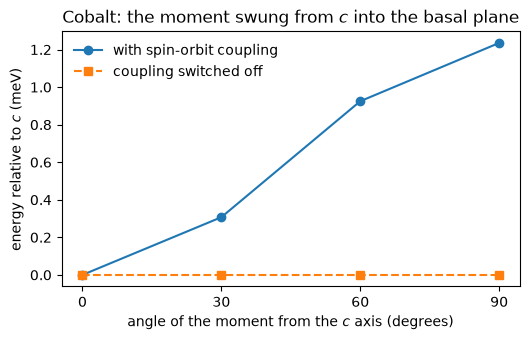

In [4]:
fig, ax = plt.subplots(figsize=(5.4, 3.5))
ax.plot(angles, curves[1.0], "o-", label="with spin-orbit coupling")
ax.plot(angles, curves[0.0], "s--", label="coupling switched off")
ax.set_xlabel("angle of the moment from the $c$ axis (degrees)")
ax.set_ylabel("energy relative to $c$ (meV)")
ax.set_title("Cobalt: the moment swung from $c$ into the basal plane")
ax.set_xticks(angles)
ax.legend(frameon=False)
fig.tight_layout()

The flat line is the whole content of the theorem. Everything that makes the
other curve bend comes from the spin-orbit term, and switching it off recovers a
crystal that does not know which way its moment points.


## The same number from one angle

Taking the anisotropy as a difference of two energies throws away most of the
precision: it is a milli-electronvolt out of a hundred Rydberg, so the two
numbers agree in seven digits before they disagree in the eighth. The **torque**
avoids that entirely. For `E(theta) = K sin^2(theta)` the slope at 45 degrees is
`K` itself, so one calculation gives the constant with nothing cancelling.

It also behaves better at a broad smearing. The torque is the slope of the
*free* energy, and in a metal the entropy carries a real part of the angle
dependence: at the smearing used here the plain band-energy difference is more
than twice the converged answer, while the torque is within a few per cent of
it.

In [5]:
torque = scalar.get_torque(spinor)

print(f"K from the torque at 45 deg      {torque.anisotropy_constant_mev:+.4f} meV")
print(f"K from the free-energy difference {mae.free_anisotropy_mev:+.4f} meV")
print(f"K from the band-energy difference {mae.anisotropy_mev:+.4f} meV")

K from the torque at 45 deg      +0.5523 meV
K from the free-energy difference +0.5523 meV
K from the band-energy difference +1.2353 meV


## Against Quantum ESPRESSO

Measured separately on the three-layer cobalt film of QE's own force-theorem
example, in-plane against out-of-plane:

| | this code | `pw.x` |
|---|---|---|
| band energy, in-plane | -75.257861 eV | -75.504327 eV |
| band energy, out-of-plane | -75.258207 eV | -75.504680 eV |
| **anisotropy** | **0.3458 meV** | **0.3532 meV** |

The two band energies are each offset by the same amount, because that film's
density is harder to converge here than in `pw.x`. A shift common to both
directions cancels in the difference, which is exactly what a theorem at frozen
density promises.

## What it will not do

A PAW dataset, because only the density is handed from the first calculation to
the second and PAW needs more than that; a Hubbard `U` or a meta-GGA, for the
same reason; an applied magnetic field, whose energy sits outside the reported
total; and a spin spiral, which has no spin-orbit coupling to switch on.

The numbers quoted against `pw.x`, and the checks behind the flat line, live in
`tests/regression/test_anisotropy.py`.